/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_5080/4112849543.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include="object").columns


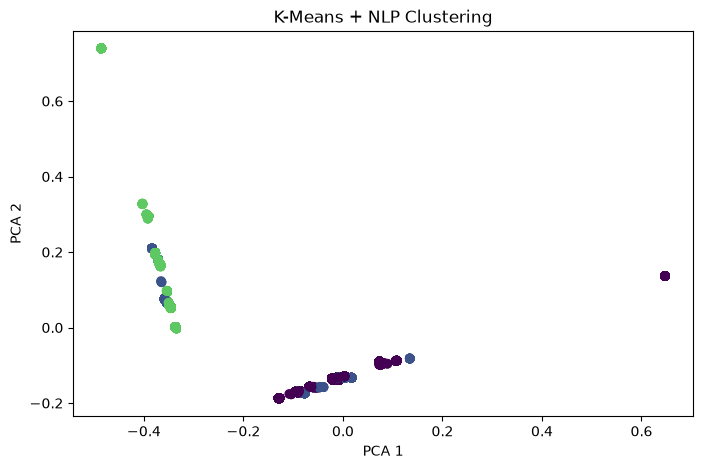

cluster
0    95755
1     2355
2     1066
3    36408
4      533
Name: count, dtype: int64


,text,cluster
0,bongo iii utc+08:00,3
1,dimito utc+08:00,3
2,dulohupa utc+08:00,3
3,harapan utc+08:00,3
4,jati mulya utc+08:00,3
5,makmur ** utc+08:00,3
6,mekar jaya utc+08:00,1
7,pangeya (pangea) utc+08:00,3
8,raharja utc+08:00,3
9,sari tani utc+08:00,3


In [1]:
# Install if needed:
# !pip install pandas scikit-learn matplotlib

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 1. Load dataset
df = pd.read_csv("geo_subdivision_idn_adm4.csv")

# 2. Find text columns and combine them
text_cols = df.select_dtypes(include="object").columns
df["text"] = df[text_cols].fillna("").agg(" ".join, axis=1)

# 3. NLP: TF-IDF
tfidf = TfidfVectorizer(
    max_features=500,
    ngram_range=(1, 2)
)
X = tfidf.fit_transform(df["text"])

# 4. K-Means
k = 5
model = KMeans(n_clusters=k, random_state=42, n_init=10)
df["cluster"] = model.fit_predict(X)

# 5. PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["cluster"])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means + NLP Clustering")
plt.show()

# 6. Cluster results
print(df["cluster"].value_counts().sort_index())
display(df[["text", "cluster"]].head(20))

# 7. Save results
df.to_csv("geo_subdivision_idn_adm4_clustered.csv", index=False)